# FWC groups time series for OHC and MLD - smaller Beaufort domain

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:39029")
client

<Client: 'tcp://127.0.0.1:39029' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

# open density zarr store - [kg m-3]
rho_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/RHOAnoma_AVG_DAILY.ZARR/', s3_options).RHOAnoma + 1027.5

In [12]:
# carve out beaufort region
salt_beaufort = salt_da.isel(i=slice(450,625),j=slice(110,390))
theta_beaufort = theta_da.isel(i=slice(450,625),j=slice(110,390))
ice_beaufort = ice_da.isel(i=slice(450,625),j=slice(110,390))
rho_beaufort = rho_da.isel(i=slice(450,625),j=slice(110,390))

grid_beaufort = HH_grid.isel(i=slice(450,625),j=slice(110,390),k=slice(0,18)) # upper 60 m

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,625),j=slice(110,390))

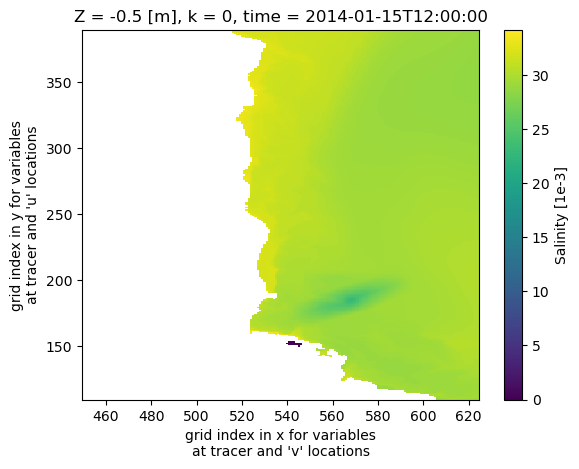

In [13]:
salt_beaufort.isel(time=0,k=0).plot()

## 1. Select days after sea ice minimum each year and mask SIC>15%

In [14]:
ice_beaufort = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,625),j=slice(110,390))
beaufort_area = HH_grid.isel(i=slice(450,625),j=slice(110,390)).rAc

In [15]:
# calculating minimum based on extend (count grid cells where ice concentration >= 15% and sum their areas)

# salculate sea ice extent: sum the area of grid cells where SIC >= 15%
ice_extent = ((ice_beaufort >= 15) * beaufort_area).sum(dim=['i', 'j'])
ice_extent = ice_extent.where(ice_extent != 0)

# group by year
grouped = ice_extent.groupby("time.year")

# find the day of the minimum extent for each year
min_ice_dates = []
for year, data in grouped:
    sic_min_yr = data['time']
    min_day_tmp = sic_min_yr[data.argmin().values].values  # Get the time corresponding to min extent
    min_ice_dates.append(min_day_tmp)
    print(f"{year}: Minimum extent on {min_day_tmp}")

2014: Minimum extent on 2014-09-23T12:00:00.000000000
2015: Minimum extent on 2015-09-16T12:00:00.000000000
2016: Minimum extent on 2016-09-01T12:00:00.000000000
2017: Minimum extent on 2017-10-06T12:00:00.000000000
2018: Minimum extent on 2018-09-21T12:00:00.000000000
2019: Minimum extent on 2019-10-05T12:00:00.000000000
2020: Minimum extent on 2020-09-06T12:00:00.000000000


In [16]:
# generate daily timestamps from each min date to Dec 31 of that year
date_arrays = [np.arange(np.datetime64(date), np.datetime64(f"{str(date)[:4]}-12-31") + np.timedelta64(1, 'D'), np.timedelta64(1, 'D'))
               for date in min_ice_dates]

# concatenate into one array
full_date_array = np.concatenate(date_arrays)

In [17]:
theta_beaufort.Z.values[0:18]

array([ -0.5  ,  -1.57 ,  -2.79 ,  -4.185,  -5.78 ,  -7.595,  -9.66 ,
       -12.01 , -14.68 , -17.705, -21.125, -24.99 , -29.345, -34.24 ,
       -39.725, -45.855, -52.69 , -60.28 ], dtype=float32)

In [18]:
# select days after sea ice minimum for theta and salinity

# select all timesteps after sea ice minimum each year
sic_yrs = ice_beaufort.sel(time=full_date_array)
temp_yrs = theta_beaufort.sel(time=full_date_array).isel(k=slice(0,18)) # upper 60 m
salt_yrs = salt_beaufort.sel(time=full_date_array).isel(k=slice(0,18)) 
rho_yrs = rho_beaufort.sel(time=full_date_array).isel(k=slice(0,18)) 

In [ ]:
# look at depth of grid cell center and bottom of grid cell
# print(salt_yrs.Z.values)
# print(HH_grid.isel(k_u=slice(0,7)).Zu.values)

In [19]:
# list to store yearly masks
mask_list = []

for date in min_ice_dates:
    year = str(date.astype('datetime64[Y]'))  # Extract year as a string
    
    # select all days from the minimum ice date to Dec 31
    yearly_data = sic_yrs.sel(time=slice(str(date), f"{year}-12-31"))

    # get sea ice concentration on the minimum ice date
    sic_min_day = sic_yrs.sel(time=date)

    # create a mask for grid cells where sic >= 15% on the minimum ice date
    mask = sic_min_day >= 15  # 2D (i, j)

    # expand mask along time dimension to match yearly_data
    mask_expanded = mask.expand_dims(dim={"time": yearly_data.time}, axis=0)

    # store in list
    mask_list.append(mask_expanded)

# combine all yearly masks
sic_yrs_mask = xr.concat(mask_list, dim="time").combine_first(sic_yrs * 0)  # Align time with sic_yrs

In [20]:
# apply mask to temperature, salinity, and density ds
land_sic_mask_yr = (~sic_yrs_mask.astype(bool)) & (HH_grid.isel(i=slice(450,625),j=slice(110,390),k=0).mask_basin)

sic_yrs_masked = sic_yrs.where(land_sic_mask_yr)
salt_yrs_masked = salt_yrs.where(land_sic_mask_yr)
rho_yrs_masked = rho_yrs.where(land_sic_mask_yr)

## 2. Calculate FWC

In [21]:
def calculate_fwc(salt_da, salt_ref, dz):
    """
    Calculate the freshwater content (fwc)

    Parameters:
    salt_da (xr.DataArray): Salinity data array with a 'k' dimension.
    salt_ref (float): Reference salinity value.
    dz (xr.DataArray): Layer thickness data array with the same 'k' dimension.

    Returns:
    xr.DataArray: Freshwater content summed over the 'k' dimension.
    """
    fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')
    return fwc

In [22]:
salt_yrs_10m = salt_yrs.isel(k=slice(0,7))

In [23]:
salt_yrs_10m.Z.values

array([-0.5  , -1.57 , -2.79 , -4.185, -5.78 , -7.595, -9.66 ],
      dtype=float32)

In [24]:
# calculate FWC

# define reference salinity
salt_ref = 34.8

# dz = HH_grid.isel(i=slice(450,625),j=slice(110,390)).drF.isel(k=slice(0,8)) # upper 12
dz = HH_grid.isel(i=slice(450,625),j=slice(110,390)).drF.isel(k=slice(0,7)) # upper 10
# dz = HH_grid.isel(i=slice(510,590),j=slice(140,260)).drF.isel(k=slice(0,7)) # upper 10

fwc_beaufort_yrs = calculate_fwc(salt_yrs_10m, salt_ref, dz)

In [25]:
# mask land grid cells and where SIC>15% on ice minimum date
# sic_yrs_masked = sic_yrs.where(land_sic_mask_yr)
fwc_yrs_masked = fwc_beaufort_yrs.where(land_sic_mask_yr)

In [26]:
fwc_over_2m = fwc_yrs_masked.where(fwc_yrs_masked>2)
fwc_under_2m = fwc_yrs_masked.where(fwc_yrs_masked<2)

In [27]:
# name dataset and save dataset to zarr
fwc_over_2m.name = 'fwc_over_2m'
fwc_over_2m.to_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/FWC/FWC_over2m_Beaufort_cut.ZARR')

fwc_under_2m.name = 'fwc_under_2m'
fwc_under_2m.to_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/FWC/FWC_under2m_Beaufort_cut.ZARR')

fwc_yrs_masked.name = 'fwc_yrs_masked'
fwc_yrs_masked.to_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/FWC/FWC_masked_Beaufort_cut.ZARR')

## 3a. Group FWC>2 and calculate mean OHC for time series

In [28]:
def calculate_cp_from_profile(salinity, temperature, depth, lon=-137, lat=70):
    """
    Calculate specific heat capacity (cp) of seawater from depth, temperature, and salinity.
    
    Parameters:
    - salinity (array): salinity (PSU)
    - temperature (array): temperature (°C)
    - depth (array): depth values (m, negative downward)
    - lon (float): longitude for SA calculation
    - lat (float): latitude for pressure calculation
    
    Args:
    - cp (array): Specific heat capacity (J/kg/deg K) for each depth level
    """
    # Convert depth (m) to pressure (dbar)
    pressure = gsw.p_from_z(depth, lat)  # Negative depth because z is negative downward
    
    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(salinity, pressure, lon, lat)
    
    # Compute specific heat capacity (cp) in J/(kg K)
    cp = gsw.cp_t_exact(SA, temperature, pressure)
    
    return cp

In [29]:
def calculate_mld(sigma0_array, density_threshold=0.03):
    """
    Calculate the Mixed Layer Depth (MLD) from a 4D potential density dataset (time, i, j, k),
    defined as the first depth where density exceeds surface density + threshold.
    
    Handles land-masked grid cells where all vertical values are NaN by returning NaN.
    Compatible with Dask via rechunking along the vertical dimension (k).

    Args:
        sigma0_array (xr.DataArray): Potential density with dims (time, i, j, k) and vertical coord 'Z'.
        density_threshold (float): Threshold above surface density to define MLD (default 0.03 kg/m³).

    Returns:
        mld (xr.DataArray): MLD (depth) with dims (time, i, j).
        mld_k_index (xr.DataArray): Index along 'k' where threshold is first exceeded (time, i, j).
    """

    # Surface density at k=0
    rho_surface = sigma0_array.isel(k=0)

    # Density threshold
    threshold = rho_surface + density_threshold

    # Depth coordinate along 'k'
    depth_coord = sigma0_array['Z']

    # Ensure vertical dim is in a single chunk for Dask
    sigma0_array = sigma0_array.chunk(dict(k=-1))

    # Helper function to return both depth and index
    def first_exceeding_level_and_index(profile, depth, threshold_val):
        if np.all(np.isnan(profile)):
            return np.nan, np.nan
        for k in range(profile.shape[0]):
            if profile[k] >= threshold_val and not np.isnan(profile[k]):
                return depth[k], k
        return np.nan, np.nan

    # Apply with vectorization and dask support
    mld, mld_k_index = xr.apply_ufunc(
        first_exceeding_level_and_index,
        sigma0_array,
        depth_coord,
        threshold,
        input_core_dims=[["k"], ["k"], []],
        output_core_dims=[[], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float],
    )

    return mld, mld_k_index

#### Calculate MLD

In [30]:
def calculate_ohc(temp, salinity, density, layer_thickness, threshold_idx):
    """
    Calculate the Ocean Heat Content (OHC) relative to the freezing temperature in surface mixed layer for a time series of profiles.

    Args:
    - temp (xr.DataArray): 2D array of temperature (°C) with dimensions ['time', 'k'].
    - salinity (xr.DataArray): 2D array of salinity (PSU) with dimensions ['time', 'k'].
    - density (xr.DataArray): 2D array of seawater density (kg/m3) with dimensions ['time', 'k'].
    - layer_thickness (xr.DataArray): 1D array representing the thickness of each vertical layer (m).
    - threshold_idx (xr.DataArray): 1D array containing the maximum depth index for the MLD of each profile along the time series.

    Returns:
    - ohc (xr.DataArray): 3D array representing ocean heat content relative to the freezing temperature in the surface mixed layer for each profile (J/m2).
    """
    
    # specific heat capacity of seawater
    cp = calculate_cp_from_profile(salinity, temp, temp.Z, lon=temp.XC, lat=temp.YC)

    # # Given array of indices
    # indices = threshold_idx.compute()

    # Create mask for surface mixed layer
    mask = temp.k <= indices
    
    # Compute ocean heat content relative to freezing temperature per unit area
    temp_freezing = -1.8

    # Compute the weighted temperature anomaly and then OHC for the surface mixed layer
    weighted_temp_anomaly = (temp - temp_freezing) * layer_thickness
    weighted_temp_anomaly_layer = weighted_temp_anomaly.where(mask) # apply mask for specific depth layer
    ohc = (density * cp * weighted_temp_anomaly_layer).sum(dim='k')  # J/m^2

    # units check: (kg/m3)(J/(kg degC))(degC * m) = J/m2
    
    return ohc

In [31]:
def compute_potential_density(SALT_day, THETA_day, ref_lat=70):
    """
    Compute potential density anomaly referenced to 0 dbar.

    Args:
    - SALT_day: DataArray containing salinity (SALT), longitude (XC), and latitude (YC).
    - THETA_day: DataArray containing potential temperature (THETA).
    - ref_lat: Reference latitude for pressure calculation (default is 70°N).

    Returns:
    - sigma0: Potential density anomaly (kg/m³ - 1000).
    """
    # Convert depth (m) to pressure (dbar)
    p = gsw.p_from_z(SALT_day.Z, ref_lat)  # Depth is negative

    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(SALT_day, p, SALT_day.XC, SALT_day.YC)

    # Convert Potential Temperature to Conservative Temperature
    CT = gsw.conversions.CT_from_pt(SA, THETA_day)

    # Calculate potential density anomaly referenced to 0 dbar
    sigma0 = gsw.sigma0(SA, CT)

    # Add metadata
    sigma0.name = 'potential_density'
    sigma0.attrs['long_name'] = 'potential_density'

    return sigma0 + 1000

In [32]:
# calculate potential density from in situ density
sigma0 = compute_potential_density(salt_yrs, temp_yrs, ref_lat=70)

In [33]:
# calculate mld and the index of the mld along k coord for EASTERN beaufort
start = time.time()
# mld_da, threshold_idx_da = calculate_mld(rho_yrs, density_threshold=0.03)
mld_da, threshold_idx_da = calculate_mld(sigma0, density_threshold=0.03)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

Time taken: 0.0 seconds


In [34]:
# name dataset and save dataset to zarr
mld_da.name = 'mld'
mld_da.to_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/MLD/MLD_Beaufort_cut.ZARR', safe_chunks=False)

In [35]:
# load into memory
mld_idx_da = threshold_idx_da.compute()

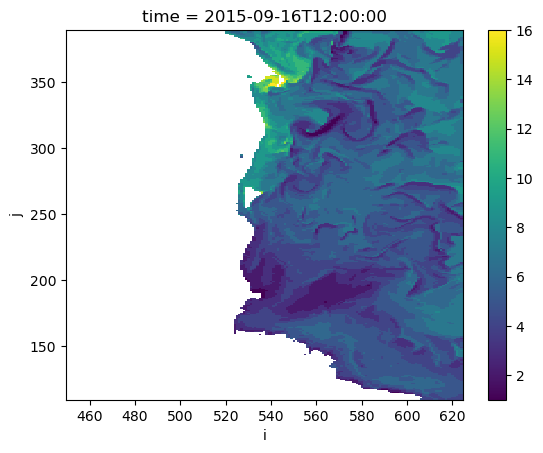

In [36]:
mld_idx_da.isel(time=100).plot();

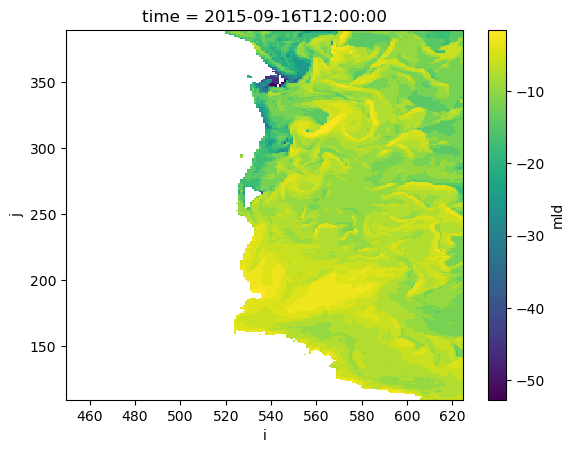

In [37]:
# sanity check to make sure it worked
mld_da.isel(time=100).plot();

#### Calculate OHC

In [38]:
def calculate_ohc(temp, salinity, density, layer_thickness, threshold_idx):
    """
    Calculate the Ocean Heat Content (OHC) relative to the freezing temperature in surface mixed layer for a time series of profiles.

    Args:
    - temp (xr.DataArray): 2D array of temperature (°C) with dimensions ['time', 'k'].
    - salinity (xr.DataArray): 2D array of salinity (PSU) with dimensions ['time', 'k'].
    - density (xr.DataArray): 2D array of seawater density (kg/m3) with dimensions ['time', 'k'].
    - layer_thickness (xr.DataArray): 1D array representing the thickness of each vertical layer (m).
    - threshold_idx (xr.DataArray): 1D array containing the maximum depth index for the MLD of each profile along the time series.

    Returns:
    - ohc (xr.DataArray): 3D array representing ocean heat content relative to the freezing temperature in the surface mixed layer for each profile (J/m2).
    """
    
    # specific heat capacity of seawater
    cp = calculate_cp_from_profile(salinity, temp, temp.Z, lon=temp.XC, lat=temp.YC)

    # # Given array of indices
    # indices = threshold_idx.compute()

    # Create mask for surface mixed layer
    mask = temp.k <= threshold_idx
    
    # Compute ocean heat content relative to freezing temperature per unit area
    temp_freezing = -1.8

    # Compute the weighted temperature anomaly and then OHC for the surface mixed layer
    weighted_temp_anomaly = (temp - temp_freezing) * layer_thickness
    weighted_temp_anomaly_layer = weighted_temp_anomaly.where(mask) # apply mask for specific depth layer
    ohc = (density * cp * weighted_temp_anomaly_layer).sum(dim='k')  # J/m^2

    # units check: (kg/m3)(J/(kg degC))(degC * m) = J/m2
    
    return ohc

In [39]:
# calculate OHC
start = time.time()
ohc_mld = calculate_ohc(temp_yrs, salt_yrs, rho_yrs, grid_beaufort.drF, mld_idx_da)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

Time taken: 12.0 seconds


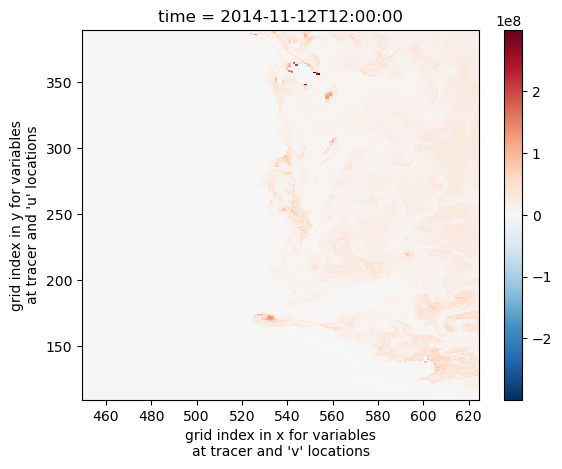

In [40]:
ohc_mld.isel(time=50).plot();

In [41]:
# name dataset and save dataset to zarr
ohc_mld.name = 'ohc'
ohc_mld.to_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/OHC/OHC_MLD_Beaufort_cut.ZARR')

In [42]:
def calculate_ohc_winterMLD(temp, salinity, density, layer_thickness, threshold_idx):
    """
    Calculate the Ocean Heat Content (OHC) relative to the freezing temperature in surface mixed layer for a time series of profiles.

    Args:
    - temp (xr.DataArray): 2D array of temperature (°C) with dimensions ['time', 'k'].
    - salinity (xr.DataArray): 2D array of salinity (PSU) with dimensions ['time', 'k'].
    - density (xr.DataArray): 2D array of seawater density (kg/m3) with dimensions ['time', 'k'].
    - layer_thickness (xr.DataArray): 1D array representing the thickness of each vertical layer (m).
    - threshold_idx (xr.DataArray): 1D array containing the maximum depth index for the MLD of each profile along the time series.

    Returns:
    - ohc (xr.DataArray): 3D array representing ocean heat content relative to the freezing temperature in the surface mixed layer for each profile (J/m2).
    """
    
    # specific heat capacity of seawater
    cp = calculate_cp_from_profile(salinity, temp, temp.Z, lon=temp.XC, lat=temp.YC)

    # Given array of indices
    # indices = threshold_idx.compute()

    # Create mask for depths between surface mixed layer and winter mixed layer (down to ~8m in this case)
    mask = (temp.k > threshold_idx) & (temp.k < 6)
    
    # Compute ocean heat content relative to freezing temperature per unit area
    temp_freezing = -1.8

    # Compute the weighted temperature anomaly and then OHC for the surface mixed layer
    weighted_temp_anomaly = (temp - temp_freezing) * layer_thickness
    weighted_temp_anomaly_layer = weighted_temp_anomaly.where(mask) # apply mask for specific depth layer
    ohc = (density * cp * weighted_temp_anomaly_layer).sum(dim='k')  # J/m^2

    # units check: (kg/m3)(J/(kg degC))(degC * m) = J/m2
    
    return ohc, mask

In [43]:
HH_grid.isel(k_u=slice(0,6)).Zu.values # k=6 grid cell goes down to 8.6 m

array([-1.  , -2.14, -3.44, -4.93, -6.63, -8.56], dtype=float32)

In [44]:
# calculate OHC between summer MLD and winter MLD
start = time.time()
ohc_mld_winter, mask_winter = calculate_ohc_winterMLD(temp_yrs, salt_yrs, rho_yrs, grid_beaufort.drF, mld_idx_da)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

Time taken: 14.0 seconds


In [45]:
# sanity check to make sure mask is good
print(mask_winter.sel(j=260,i=560).isel(time=10).values)
print(mld_idx_da.sel(j=260,i=560).isel(time=10).values)

[False False False  True  True  True False False False False False False
 False False False False False False]
2.0


In [46]:
# name dataset and save dataset to zarr
ohc_mld_winter.name = 'ohc_winter'
ohc_mld_winter.to_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/OHC/OHC_MLD_winter_Beaufort_cut.ZARR')

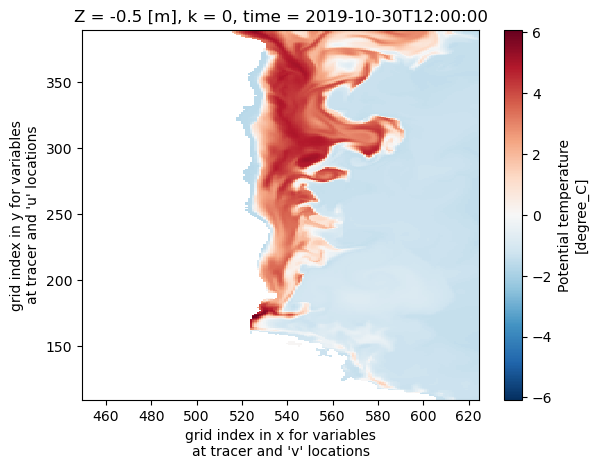

In [48]:
temp_yrs.sel(time='2019-10-30').isel(k=0).plot();

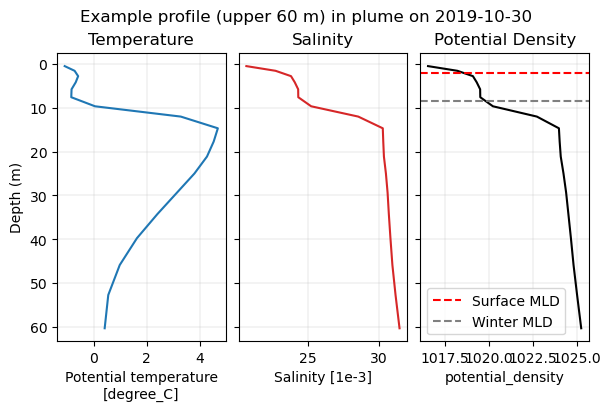

In [50]:
# sanity check plots
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[6,4],sharey=True,layout='constrained')
temp_yrs.sel(i=560,j=190,time='2019-10-30').plot(ax=ax1,y='Z',color='tab:blue');
salt_yrs.sel(i=560,j=190,time='2019-10-30').plot(ax=ax2,y='Z',color='tab:red');
sigma0.sel(i=560,j=190,time='2019-10-30').plot(ax=ax3,y='Z',color='k');

# MLD
# ax3.axhline(y=mld_da.sel(i=560,j=190,time='2019-10-30').values,color='r',linestyle='dashed',label='Surface MLD')
# We want to show the bottom depth of the MLD grid cell
mld_bottom = grid_beaufort.isel(k_u=int(threshold_idx_da.sel(i=560,j=190,time='2019-10-30').values[0])).Zu.values
ax3.axhline(y=mld_bottom,color='r',linestyle='dashed',label='Surface MLD')

# bottom of winter MLD
mld_winter_bottom = grid_beaufort.isel(k_u=5).Zu.values
ax3.axhline(y=mld_winter_bottom,color='gray',linestyle='dashed',label='Winter MLD')
ax3.legend()

ax1.set_title('Temperature')
ax1.set_yticks(np.arange(0,-70,-10))
ax1.set_yticklabels(np.arange(0,70,10))
ax2.set_title('Salinity')
ax3.set_title('Potential Density');

for ax in (ax1,ax2,ax3):
    ax.set_ylabel("")
    ax.grid(linewidth=0.2)
ax1.set_ylabel('Depth (m)')
plt.suptitle('Example profile (upper 60 m) in plume on 2019-10-30');

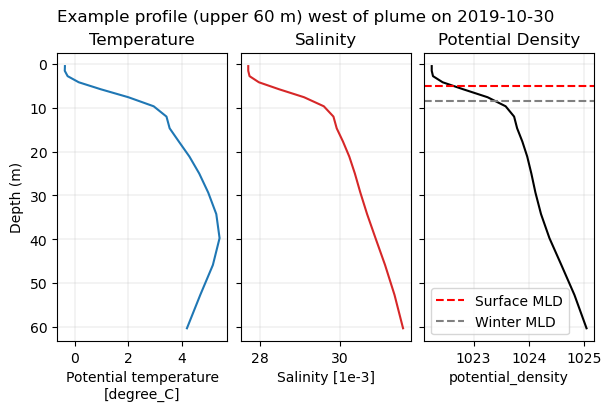

In [51]:
# sanity check plots
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[6,4],sharey=True,layout='constrained')
temp_yrs.sel(i=560,j=300,time='2019-10-30').plot(ax=ax1,y='Z',color='tab:blue');
salt_yrs.sel(i=560,j=300,time='2019-10-30').plot(ax=ax2,y='Z',color='tab:red');
sigma0.sel(i=560,j=300,time='2019-10-30').plot(ax=ax3,y='Z',color='k');

# MLD
# ax3.axhline(y=mld_da.sel(i=560,j=190,time='2019-10-30').values,color='r',linestyle='dashed',label='Surface MLD')
# We want to show the bottom depth of the MLD grid cell
mld_bottom = grid_beaufort.isel(k_u=int(threshold_idx_da.sel(i=560,j=300,time='2019-10-30').values[0])).Zu.values
ax3.axhline(y=mld_bottom,color='r',linestyle='dashed',label='Surface MLD')

# bottom of winter MLD
mld_winter_bottom = grid_beaufort.isel(k_u=5).Zu.values
ax3.axhline(y=mld_winter_bottom,color='gray',linestyle='dashed',label='Winter MLD')
ax3.legend()

ax1.set_title('Temperature')
ax1.set_yticks(np.arange(0,-70,-10))
ax1.set_yticklabels(np.arange(0,70,10))
ax2.set_title('Salinity')
ax3.set_title('Potential Density');

for ax in (ax1,ax2,ax3):
    ax.set_ylabel("")
    ax.grid(linewidth=0.2)
ax1.set_ylabel('Depth (m)')
plt.suptitle('Example profile (upper 60 m) west of plume on 2019-10-30');

#### Select grid cells above and below FCW of 2 m

In [52]:
# open FWC dataset
fwc_yrs_masked = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/FWC/FWC_masked_Beaufort_cut.ZARR')
fwc_yrs_masked = fwc_yrs_masked.fwc_yrs_masked

In [53]:
# open OHC zarr stores
ohc_mld_ds = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/OHC/OHC_MLD_Beaufort_cut.ZARR')
ohc_mld_win_ds = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/OHC/OHC_MLD_winter_Beaufort_cut.ZARR')

In [54]:
# select all cells with FWC above and below 2
ohc_fwc_over_2m = ohc_mld_ds.ohc.where(fwc_yrs_masked>2).load()
ohc_fwc_under_2m = ohc_mld_ds.ohc.where(fwc_yrs_masked<2).load()

ohc_below_fwc_over_2m = ohc_mld_win_ds.ohc_winter.where(fwc_yrs_masked>2).load()
ohc_below_fwc_under_2m = ohc_mld_win_ds.ohc_winter.where(fwc_yrs_masked<2).load()

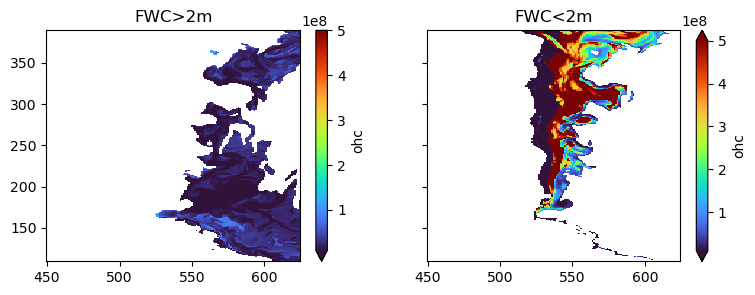

In [55]:
# sanity check plots
fig, (ax1,ax2) = plt.subplots(1,2,sharex=True,sharey=True,figsize=[9,3])
ohc_fwc_over_2m.sel(time='2019-10-30').plot(ax=ax1,vmin=1e7,vmax=5e8,cmap='turbo');
ohc_fwc_under_2m.sel(time='2019-10-30').plot(ax=ax2,vmin=1e7,vmax=5e8,cmap='turbo');
ax1.set_title('FWC>2m')
ax2.set_title('FWC<2m')
ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("")
ax2.set_ylabel("");

## Plot OHC in ML for FWC above and below 2 m

In [56]:
# look at SIC for the same FWC grouping
# select all cells with FWC above and below 2
ice_fwc_over_2m = sic_yrs.where(fwc_yrs_masked>2).load()
ice_fwc_under_2m = sic_yrs.where(fwc_yrs_masked<2).load()

### Add vertical lines for where SIC>=15% and remain above it for at least 5 days


In [57]:
# first day when sea ice concentration (SIC) reaches or exceeds 15% and stays above that threshold for at least 5 consecutive days
years = np.arange(2014, 2021)

ice_fwc_over_2m_dates = []
ice_fwc_under_2m_dates = []

for year in years:
    # Compute mean SIC over space
    ice_over_mean = ice_fwc_over_2m.sel(time=str(year)).mean(dim=['i', 'j'], skipna=True).compute()
    ice_under_mean = ice_fwc_under_2m.sel(time=str(year)).mean(dim=['i', 'j'], skipna=True).compute()
    
    # Convert to boolean where SIC >= 15
    ice_over_bool = ice_over_mean >= 15
    ice_under_bool = ice_under_mean >= 15

    # Find the first day where there are 5+ consecutive True values
    def find_persistent_threshold(bool_array, time_array, window=5):
        bool_np = bool_array.values
        for i in range(len(bool_np) - window + 1):
            if np.all(bool_np[i:i+window]):
                return time_array[i].values
        return np.datetime64('NaT')  # If no valid period found

    over_time = ice_over_mean['time']
    under_time = ice_under_mean['time']

    ice_over_date = find_persistent_threshold(ice_over_bool, over_time)
    ice_under_date = find_persistent_threshold(ice_under_bool, under_time)

    ice_fwc_over_2m_dates.append(ice_over_date)
    ice_fwc_under_2m_dates.append(ice_under_date)

### Plot all years

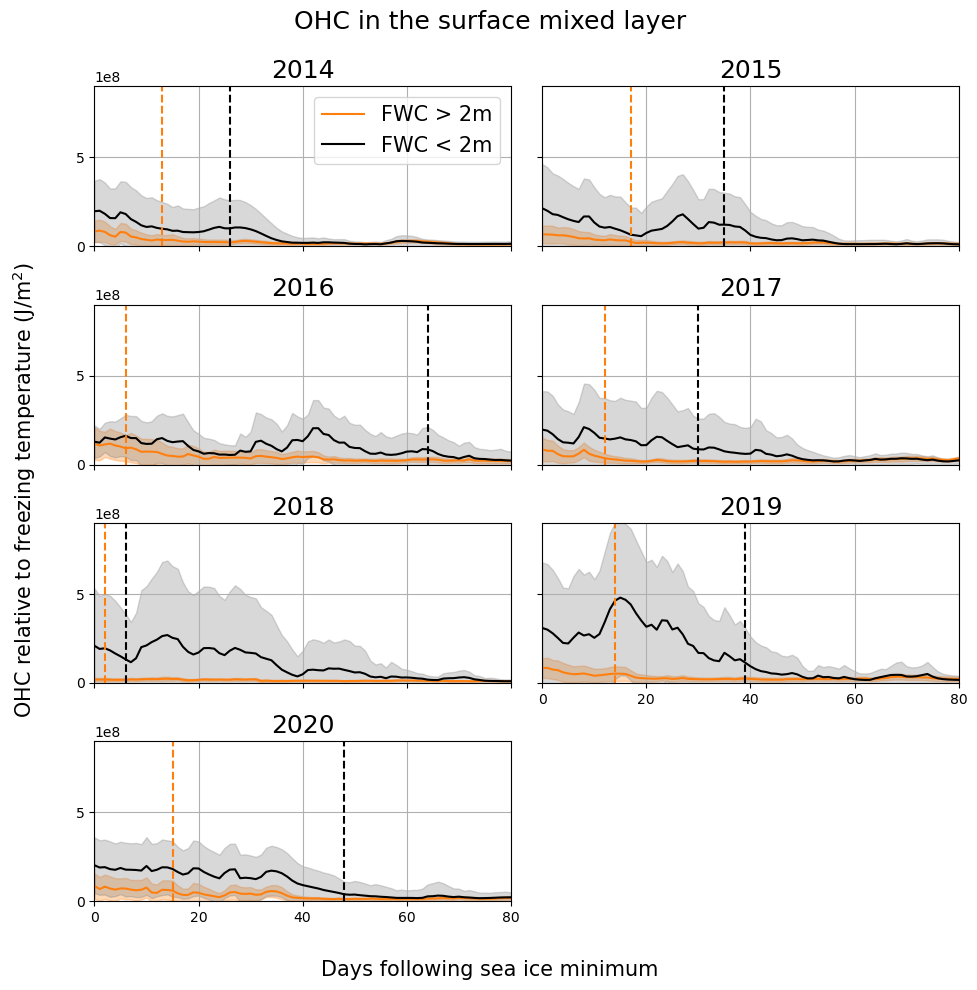

In [58]:
years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[10, 10], sharex=True, sharey=True)
plt.rcParams['font.size'] = 15
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_over = ohc_fwc_over_2m.sel(time=str(year))
    data_under = ohc_fwc_under_2m.sel(time=str(year))

    # Find first day when sea ice exists (mean_over is not NaN or > 0)
    mean_over = data_over.mean(dim=['i', 'j'])
    first_valid_index = mean_over.notnull().argmax().compute().item()
    
    # Extract the shifted data starting from sea ice onset
    mean_over = mean_over.isel(time=slice(first_valid_index, None))
    mean_under = data_under.mean(dim=['i', 'j']).isel(time=slice(first_valid_index, None))

    # Recalculate SE for the sliced data
    data_over_slice = data_over.isel(time=slice(first_valid_index, None))
    data_under_slice = data_under.isel(time=slice(first_valid_index, None))

    std_over = data_over_slice.std(dim=['i', 'j'])
    std_under = data_under_slice.std(dim=['i', 'j'])

    # Reset x-axis to be relative to the start of sea ice
    doy_shifted = np.arange(len(mean_over))

    # Plot
    ax.plot(doy_shifted, mean_over, color='tab:orange', label='FWC > 2m')
    ax.fill_between(doy_shifted, mean_over - std_over, mean_over + std_over, color='tab:orange', alpha=0.3)

    ax.plot(doy_shifted, mean_under, color='k', label='FWC < 2m')
    ax.fill_between(doy_shifted, mean_under - std_under, mean_under + std_under, color='gray', alpha=0.3)

    # add vertical lines for where SIC > 15%
    ax.axvline(x=np.where(data_over_slice.time.values == ice_fwc_over_2m_dates[i])[0][0], color='tab:orange', linestyle='dashed')
    ax.axvline(x=np.where(data_under_slice.time.values == ice_fwc_under_2m_dates[i])[0][0], color='k', linestyle='dashed')

    ax.set_title(f"{year}")
    ax.set_xlim([0, 80])
    ax.set_ylim([0, 9e8])
    ax.grid(True)

    if i == 5:
        ax.tick_params(labelbottom=True)        
    
# axes[6].set_xlabel("Days following sea ice minimum")

# Turn off the last axis if unused (e.g., 8th subplot)
if len(years) < len(axes):
    axes[-1].axis('off')

# Add legend to the first axis
axes[0].legend(loc='upper right')

fig.supxlabel("Days following sea ice minimum", fontsize=15)
fig.supylabel("OHC relative to freezing temperature (J/m$^2$)", fontsize=15)
fig.suptitle("OHC in the surface mixed layer")

plt.tight_layout()
plt.show()

## Plot OHC in between surface and winter ML for FWC above and below 2 m

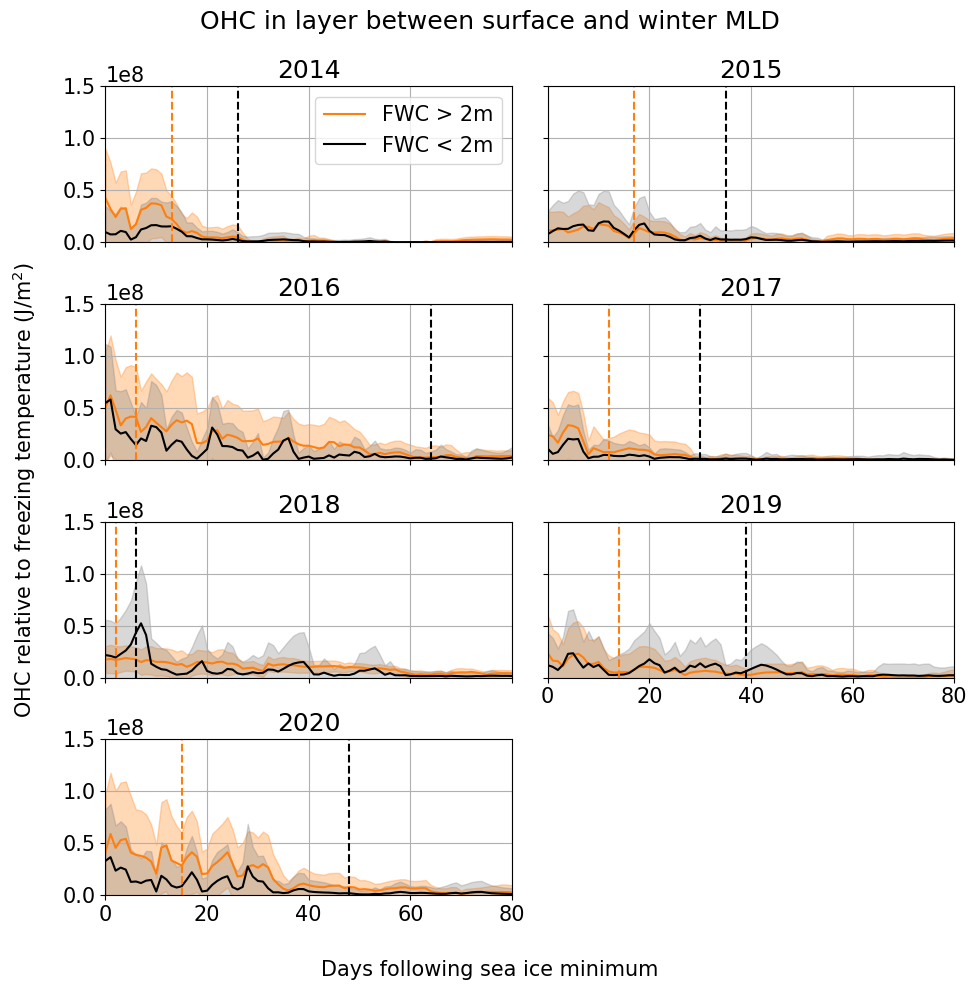

In [59]:
years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[10, 10], sharex=True, sharey=True)
plt.rcParams['font.size'] = 15
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_over = ohc_below_fwc_over_2m.sel(time=str(year))
    data_under = ohc_below_fwc_under_2m.sel(time=str(year))

    # Find first day when sea ice exists (mean_over is not NaN or > 0)
    mean_over = data_over.mean(dim=['i', 'j'])
    first_valid_index = mean_over.notnull().argmax().compute().item()
    
    # Extract the shifted data starting from sea ice onset
    mean_over = mean_over.isel(time=slice(first_valid_index, None))
    mean_under = data_under.mean(dim=['i', 'j']).isel(time=slice(first_valid_index, None))

    # Recalculate SE for the sliced data
    data_over_slice = data_over.isel(time=slice(first_valid_index, None))
    data_under_slice = data_under.isel(time=slice(first_valid_index, None))

    std_over = data_over_slice.std(dim=['i', 'j'])
    std_under = data_under_slice.std(dim=['i', 'j'])

    # Reset x-axis to be relative to the start of sea ice
    doy_shifted = np.arange(len(mean_over))

    # Plot
    ax.plot(doy_shifted, mean_over, color='tab:orange', label='FWC > 2m')
    ax.fill_between(doy_shifted, mean_over - std_over, mean_over + std_over, color='tab:orange', alpha=0.3)

    ax.plot(doy_shifted, mean_under, color='k', label='FWC < 2m')
    ax.fill_between(doy_shifted, mean_under - std_under, mean_under + std_under, color='gray', alpha=0.3)

    # add vertical lines for where SIC > 15%
    ax.axvline(x=np.where(data_over_slice.time.values == ice_fwc_over_2m_dates[i])[0][0], color='tab:orange', linestyle='dashed')
    ax.axvline(x=np.where(data_under_slice.time.values == ice_fwc_under_2m_dates[i])[0][0], color='k', linestyle='dashed')

    ax.set_title(f"{year}")
    ax.set_xlim([0, 80])
    ax.set_ylim([0, 1.5e8])
    ax.grid(True)

    if i == 5:
        ax.tick_params(labelbottom=True)        
    
# axes[6].set_xlabel("Days following sea ice minimum")

# Turn off the last axis if unused (e.g., 8th subplot)
if len(years) < len(axes):
    axes[-1].axis('off')

# Add legend to the first axis
axes[0].legend(loc='upper right')

fig.supxlabel("Days following sea ice minimum", fontsize=15)
fig.supylabel("OHC relative to freezing temperature (J/m$^2$)", fontsize=15)
fig.suptitle("OHC in layer between surface and winter MLD")

plt.tight_layout()
plt.show()

## Plot MLD

In [60]:
mld_da = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/MLD/MLD_Beaufort_cut.ZARR')

In [61]:
# select all cells with FWC above and below 2
mld_fwc_over_2m = (mld_da.mld.where(fwc_yrs_masked>2)*-1).load()
mld_fwc_under_2m = (mld_da.mld.where(fwc_yrs_masked<2)*-1).load()

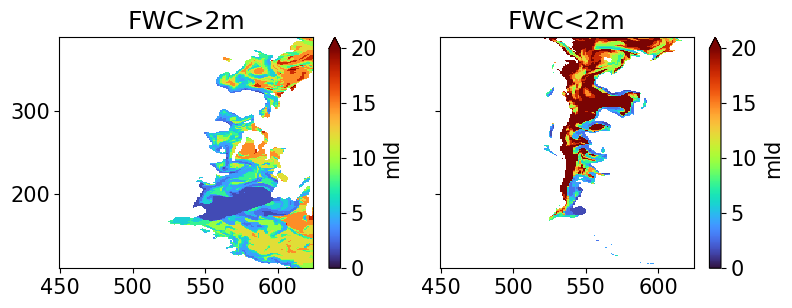

In [62]:
# sanity check plots
fig, (ax1,ax2) = plt.subplots(1,2,sharex=True,sharey=True,figsize=[9,3])
mld_fwc_over_2m.sel(time='2019-10-30').plot(ax=ax1,vmin=0,vmax=20,cmap='turbo');
mld_fwc_under_2m.sel(time='2019-10-30').plot(ax=ax2,vmin=0,vmax=20,cmap='turbo');
ax1.set_title('FWC>2m')
ax2.set_title('FWC<2m')
ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("")
ax2.set_ylabel("");

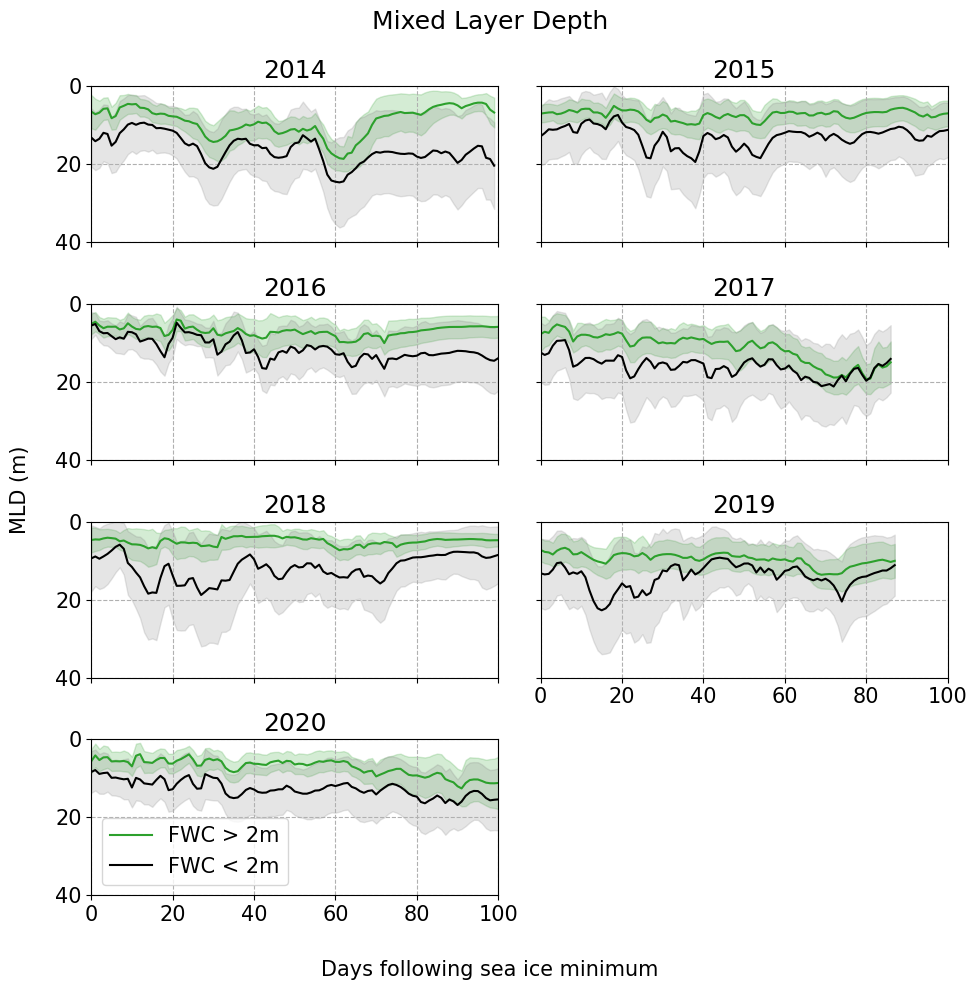

In [63]:
years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[10, 10], sharex=True, sharey=True)
plt.rcParams['font.size'] = 15
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_over = mld_fwc_over_2m.sel(time=str(year))
    data_under = mld_fwc_under_2m.sel(time=str(year))

    # Find first day when sea ice exists (mean_over is not NaN or > 0)
    mean_over = data_over.mean(dim=['i', 'j'])
    first_valid_index = mean_over.notnull().argmax().compute().item()
    
    # Extract the shifted data starting from sea ice onset
    mean_over = mean_over.isel(time=slice(first_valid_index, None))
    mean_under = data_under.mean(dim=['i', 'j']).isel(time=slice(first_valid_index, None))

    # Recalculate SE for the sliced data
    data_over_slice = data_over.isel(time=slice(first_valid_index, None))
    data_under_slice = data_under.isel(time=slice(first_valid_index, None))

    std_over = data_over_slice.std(dim=['i', 'j'])
    std_under = data_under_slice.std(dim=['i', 'j'])

    # Reset x-axis to be relative to the start of sea ice
    doy_shifted = np.arange(len(mean_over))

    # Plot
    ax.plot(doy_shifted, mean_over, color='tab:green', label='FWC > 2m')
    ax.fill_between(doy_shifted, mean_over - std_over, mean_over + std_over, color='tab:green', alpha=0.2)

    ax.plot(doy_shifted, mean_under, color='k', label='FWC < 2m')
    ax.fill_between(doy_shifted, mean_under - std_under, mean_under + std_under, color='gray', alpha=0.2)

    ax.set_title(f"{year}")
    ax.set_xlim([0, 100])
    ax.set_ylim([40, 0])
    # ax.set_yticks([2, 4, 6, 8, 10])
    ax.grid(True,linestyle='dashed')

    if i == 5:
        ax.tick_params(labelbottom=True)        
    
# axes[6].set_xlabel("Days following sea ice minimum")

# Turn off the last axis if unused (e.g., 8th subplot)
if len(years) < len(axes):
    axes[-1].axis('off')

# Add legend to the first axis
axes[-2].legend(loc='lower left')

fig.supxlabel("Days following sea ice minimum", fontsize=15)
fig.supylabel("MLD (m)", fontsize=15)
fig.suptitle("Mixed Layer Depth")

plt.tight_layout()
plt.show()